## 分析用関数などセットアップ

In [1]:
# ライブラリのインポート
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import sys
from pathlib import Path

# プロジェクトルートを sys.path に追加
project_root = Path.cwd()
sys.path.insert(0, str(project_root / "src"))
# プロジェクトルートの設定をしておかないと my_utils が import できない
import my_utils.array_logger as array_logger
from my_utils.array_logger import ArrayReader

print("✓ ライブラリインポート完了")

api = wandb.Api()

def load_array_log_df(run_id: str, array_name: str) -> pd.DataFrame:
    # ArrayReader でデータを DataFrame として読み込む
    db_path = project_root / "results" / "array_logs" / run_id / f"{array_name}.db"
    reader = ArrayReader(str(db_path))
    reader.open()
    df = reader.to_dataframe()
    reader.close()
    # print(f"✓ 読み込み完了！")
    # print(f"\nデータ形状: {df.shape}")
    # print(f"\narrayの形状: {df['array'].iloc[0].shape}")
    # print(f"\n最初の3行:")
    # print(df.head(10))
    return df

✓ ライブラリインポート完了


## wandbのrunを検索して runs に格納

In [35]:
import pprint

filters = {
    "$and": [
        {"created_at": {"$gte": "2026-01-04T00:00:00"}}, # gte: Greater Than or Equal (以上)
        {"state": "finished"},
        {"display_name": "10a10f_lc1"},
        # {"config.enable_fixed_wait_action_prob": True},
        # {"config.fixed_wait_action_prob": 0},
    ]
}
runs = api.runs("kazuyasakakibara/FoodBank2025", filters=filters)

print("filters:")
pprint.pprint(filters)
print(f"{len(runs)} 件の実験データを取得しました。")

# # test_completedの値でrunを分類
# completed_values = [run.summary.get("test_completed") for run in runs]
# completed_counts = pd.Series(completed_values).value_counts().sort_index()
# print(completed_counts)

# print("\n=== test_completed別の割合 ===")
# completed_ratio = completed_counts / len(runs)
# for completed, ratio in completed_ratio.items():
#     print(f"{completed}: {ratio:.2f}")
# print(f"（成功率: {completed_ratio[1]:.2f}）")

filters:
{'$and': [{'created_at': {'$gte': '2026-01-04T00:00:00'}},
          {'state': 'finished'},
          {'display_name': '10a10f_lc1'}]}
30 件の実験データを取得しました。


# 

## lossの分布

   t_env                  array
0    562    [2.445773124694824]
1    579  [0.21526512503623962]
2    597   [2.1331467628479004]
3    615   [1.9029521942138672]
4    633   [0.7001734972000122]
5    650  [0.15041248500347137]
6    668   [0.3483310639858246]
7    686  [0.31001514196395874]
8    703  [0.13500770926475525]
9    720   [0.2611157298088074]

=== データ型の確認 ===
arrayカラムのデータ型: object
array内の要素の型（最初の5件）:
  0: type=<class 'numpy.ndarray'>, shape=(1,), dtype=float64
  1: type=<class 'numpy.ndarray'>, shape=(1,), dtype=float64
  2: type=<class 'numpy.ndarray'>, shape=(1,), dtype=float64
  3: type=<class 'numpy.ndarray'>, shape=(1,), dtype=float64
  4: type=<class 'numpy.ndarray'>, shape=(1,), dtype=float64

=== 異常値のチェック ===
NaNの数: 0
配列内にNaNを含む行数: 0
配列内に無限大を含む行数: 0


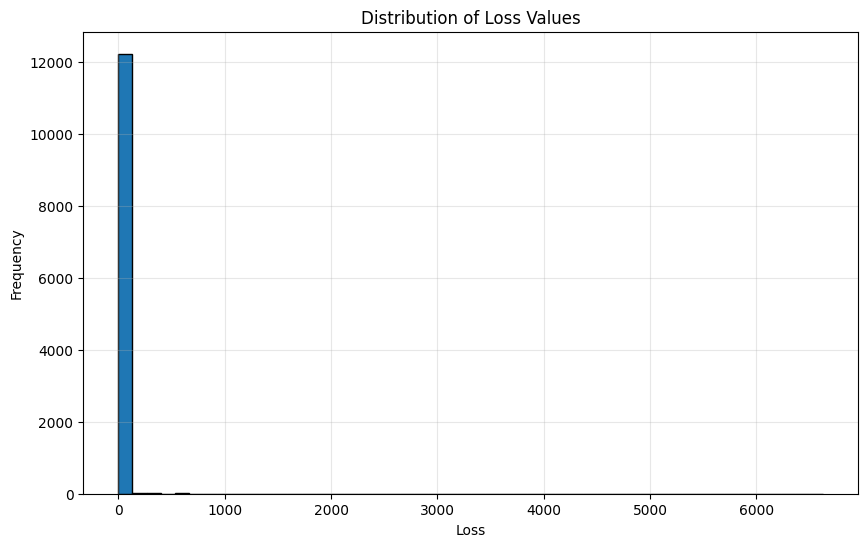


=== Loss の基本統計量 ===
平均: 5.035490
中央値: 0.018974
標準偏差: 108.070298
最小値: 0.000464
最大値: 6625.184570


In [14]:
df = load_array_log_df("dummy", "loss")
print(df.head(10))

# lossに数値以外が含まれていないか確認
print("\n=== データ型の確認 ===")
print(f"arrayカラムのデータ型: {df['array'].dtype}")
print(f"array内の要素の型（最初の5件）:")
for i in range(min(5, len(df))):
    arr = df['array'].iloc[i]
    print(f"  {i}: type={type(arr)}, shape={arr.shape if hasattr(arr, 'shape') else 'N/A'}, dtype={arr.dtype if hasattr(arr, 'dtype') else 'N/A'}")

# NaNや無限大の値をチェック
print("\n=== 異常値のチェック ===")
print(f"NaNの数: {df['array'].isna().sum()}")
print(f"配列内にNaNを含む行数: {df['array'].apply(lambda x: np.isnan(x).any()).sum()}")
print(f"配列内に無限大を含む行数: {df['array'].apply(lambda x: np.isinf(x).any()).sum()}")

# arrayカラムから loss の値を取り出す
losses = df['array'].apply(lambda x: x[0])

# ヒストグラムをプロット
plt.figure(figsize=(10, 6))
plt.hist(losses, bins=50, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Distribution of Loss Values')
plt.grid(True, alpha=0.3)
plt.show()

# 基本統計量を表示
print("\n=== Loss の基本統計量 ===")
print(f"平均: {losses.mean():.6f}")
print(f"中央値: {losses.median():.6f}")
print(f"標準偏差: {losses.std():.6f}")
print(f"最小値: {losses.min():.6f}")
print(f"最大値: {losses.max():.6f}")

抽出後のデータ数: 91
      t_env                 array
2641  46748  [39.395694732666016]
2653  46957  [12.431583404541016]
2697  47728   [20.12160301208496]
2739  48463  [11.521934509277344]
2772  49041   [24.42654800415039]
...     ...                   ...
4948  87199   [545.2003784179688]
4951  87250  [227.92164611816406]
5028  88593  [1376.1187744140625]
5197  91552   [1425.778564453125]
5296  93293   [1352.099365234375]

[91 rows x 2 columns]

=== 抽出したlossに対応するtd_error ===
    t_env            array_loss  \
0   46748  [39.395694732666016]   
1   46957  [12.431583404541016]   
2   47728   [20.12160301208496]   
3   48463  [11.521934509277344]   
4   49041   [24.42654800415039]   
..    ...                   ...   
86  87199   [545.2003784179688]   
87  87250  [227.92164611816406]   
88  88593  [1376.1187744140625]   
89  91552   [1425.778564453125]   
90  93293   [1352.099365234375]   

                                       array_td_error  
0   [[[0.34653568], [0.08526325], [0.01791215], 

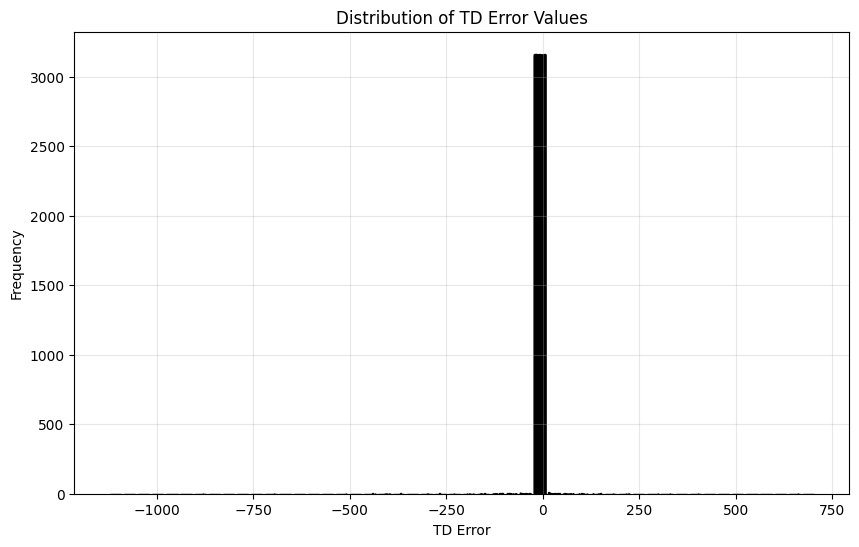

In [3]:
# lossの値が極端に大きい行だけを抽出
loss_df = load_array_log_df("stc8tzl7", "loss")
filtered_loss_df = loss_df[loss_df['array'].apply(lambda x: x[0] > 10)]
print(f"抽出後のデータ数: {len(filtered_loss_df)}")
print(filtered_loss_df)

# 抽出後のlossと同じt_envのtd_errorを抽出し、全array_td_errorの値の分布をプロット
td_error_df = load_array_log_df("stc8tzl7", "td_error")
merged_df = pd.merge(filtered_loss_df, td_error_df, on='t_env', suffixes=('_loss', '_td_error'))
print("\n=== 抽出したlossに対応するtd_error ===")
print(merged_df[['t_env', 'array_loss', 'array_td_error']])

plt.figure(figsize=(10, 6))
plt.hist(merged_df['array_td_error'], bins=50, edgecolor='black')
plt.xlabel('TD Error')
plt.ylabel('Frequency')
plt.title('Distribution of TD Error Values')
plt.grid(True, alpha=0.3)
plt.show()




=== ヒートマップビューアの操作方法 ===
↑ キー: 前の行のndarrayを表示
↓ キー: 次の行のndarrayを表示
q キー: ビューアを閉じる


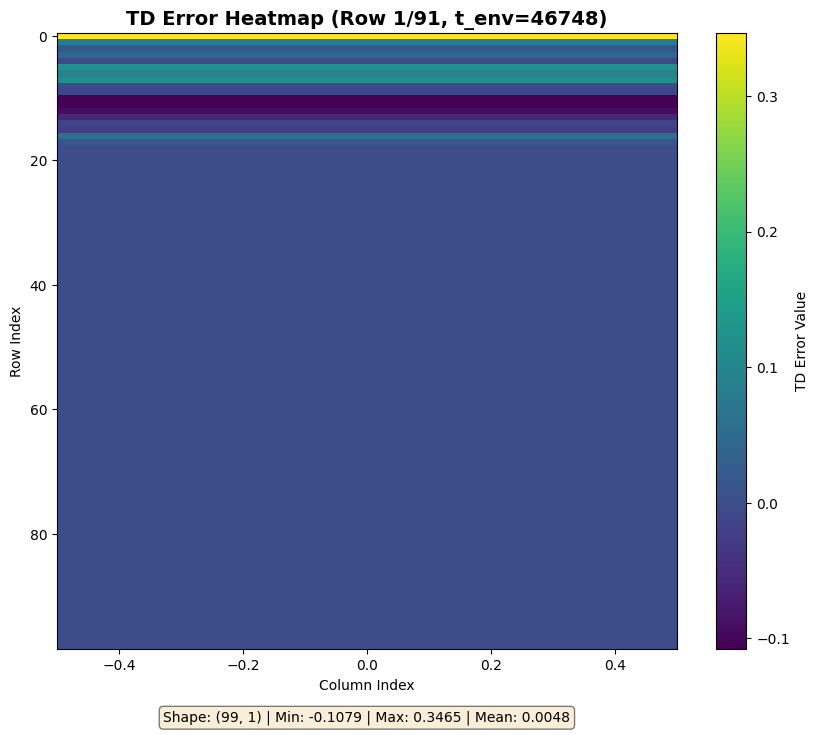

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

class HeatmapViewer:
    def __init__(self, df, array_col='array_td_error', t_env_col='t_env'):
        """
        二次元ndarrayをヒートマップで可視化するGUIビューア
        
        Parameters:
        -----------
        df : pandas.DataFrame
            データフレーム
        array_col : str
            二次元ndarrayが格納されている列名
        t_env_col : str
            時間環境情報が格納されている列名
        """
        self.df = df.reset_index(drop=True)
        self.array_col = array_col
        self.t_env_col = t_env_col
        self.current_idx = 0
        
        # matplotlibのインタラクティブモードを有効化
        plt.ion()
        
        # 図とサブプロットを作成
        self.fig, self.ax = plt.subplots(figsize=(10, 8))
        self.fig.canvas.manager.set_window_title('TD Error Heatmap Viewer')
        
        # キーボードイベントを接続
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # 初回描画
        self.update_plot()
        
        # 操作説明を表示
        print("=== ヒートマップビューアの操作方法 ===")
        print("↑ キー: 前の行のndarrayを表示")
        print("↓ キー: 次の行のndarrayを表示")
        print("q キー: ビューアを閉じる")
        print("=====================================")
        
    def on_key_press(self, event):
        """キーボードイベントのハンドラ"""
        if event.key == 'up':
            # 前の行へ移動
            if self.current_idx > 0:
                self.current_idx -= 1
                self.update_plot()
        elif event.key == 'down':
            # 次の行へ移動
            if self.current_idx < len(self.df) - 1:
                self.current_idx += 1
                self.update_plot()
        elif event.key == 'q':
            # ビューアを閉じる
            plt.close(self.fig)
            print("ビューアを閉じました")
    
    def update_plot(self):
        """現在のインデックスのndarrayをヒートマップとして描画"""
        self.ax.clear()
        
        # 現在の行のデータを取得
        current_row = self.df.iloc[self.current_idx]
        array_data = current_row[self.array_col]
        t_env = current_row[self.t_env_col]
        
        # ndarrayを二次元配列として取得
        if isinstance(array_data, np.ndarray):
            if array_data.ndim == 1:
                # 1次元の場合は、行ベクトルとして表示
                array_data = array_data.reshape(1, -1)
            elif array_data.ndim > 2:
                # 3次元以上の場合は最初の2次元だけ表示
                array_data = array_data[0]
        
        # ヒートマップを描画
        im = self.ax.imshow(array_data, cmap='viridis', aspect='auto', interpolation='nearest')
        
        # カラーバーを追加
        if hasattr(self, 'cbar'):
            self.cbar.remove()
        self.cbar = self.fig.colorbar(im, ax=self.ax)
        self.cbar.set_label('TD Error Value')
        
        # タイトルと軸ラベルを設定
        self.ax.set_title(f'TD Error Heatmap (Row {self.current_idx + 1}/{len(self.df)}, t_env={t_env})', 
                         fontsize=14, fontweight='bold')
        self.ax.set_xlabel('Column Index')
        self.ax.set_ylabel('Row Index')
        
        # グリッド表示
        self.ax.grid(False)
        
        # 配列の統計情報を表示
        stats_text = f'Shape: {array_data.shape} | Min: {array_data.min():.4f} | Max: {array_data.max():.4f} | Mean: {array_data.mean():.4f}'
        self.ax.text(0.5, -0.1, stats_text, transform=self.ax.transAxes, 
                    ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 描画を更新
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()

# ビューアを起動
viewer = HeatmapViewer(merged_df)
plt.show(block=True)